# Part 3 — Deep Learning Methods

In this notebook we demonstrate **multi-omic integration using neural network encoders**.

The data are:

| File | Description |
|------|-------------|
| `transcriptomics.pkl` | Gene-expression features |
| `proteomics.pkl` | Protein-abundance features |
| `methylation.pkl` | DNA-methylation features |

Each table is already sample-aligned, has no missing patient data, and uses the patient ID as the index.  
The prediction target is the `subtype` column.

---

## Glossary of Terms

## Workshop goals

1. Understand what a neural network is.
2. Build a simple **early-integration** neural network.
3. Build a **multi-modal encoder** with one encoder per omic view.
4. Compare both approaches using the same train/test split.
5. Extract a learned embedding space and visualise it with **t-SNE**.

## Key takeaways

- Deep learning methods can combine information shared across omics with information specific to individual omics.
- Supervised neural networks learn representations useful for the prediction task.
- Multi-modal encoder embeddings can be reused as compact multi-omic patient profiles.

## Outcome

By the end of this notebook you will have a trained neural network that produces patient-level multi-omic embeddings, visualised in 2-D with t-SNE.

## Glossary

Quick reference for terminology used throughout this notebook.

| Term | Definition |
|------|------------|
| **Neural network** | A model made of layers of connected "neurons" (weighted sums followed by a non-linear activation) that learns to map inputs to outputs by adjusting weights during training. |
| **Concatenation** | Joining two or more arrays end-to-end along a given axis — here, stacking feature vectors from different omics side by side into one longer vector. |
| **Multi-layer perceptron (MLP)** | A basic type of neural network consisting of one or more fully-connected (`Linear`) layers stacked with non-linear activations in between. |
| **Early integration** | A fusion strategy that concatenates all data views (omics) into a single feature matrix *before* passing them into a model. |
| **Multi-modal encoder** | A fusion strategy that trains a separate encoder for each data view first, then combines (concatenates) the resulting embeddings before a shared classifier. |
| **Encoder** | The part of a neural network that compresses raw input features into a lower-dimensional internal representation (an embedding). |
| **Embedding** | A dense, lower-dimensional numeric vector that represents an input (e.g. a patient's omics profile) in a way that preserves useful structure for downstream tasks. |
| **Linear layer** | A neural network layer that applies a weighted sum plus a bias to its inputs (`y = Wx + b`); the basic building block of an MLP. |
| **ReLU (Rectified Linear Unit)** | A non-linear activation function, `f(x) = max(0, x)`, applied after linear layers so the network can learn non-linear relationships. |
| **Dropout** | A regularisation technique that randomly "switches off" a fraction of neurons during training to reduce overfitting. |
| **Batch / mini-batch** | A small subset of training samples processed together in one forward/backward pass, rather than using the whole dataset at once. |
| **Epoch** | One complete pass through the entire training dataset during model training. |
| **DataLoader** | A PyTorch utility that wraps a dataset and serves it in shuffled mini-batches during training/evaluation. |
| **Cross-entropy loss** | A loss function commonly used for multi-class classification; it measures how well the predicted class probabilities match the true labels. |
| **Adam optimiser** | An adaptive gradient-descent algorithm commonly used to update neural network weights during training. |
| **Weight decay (L2 regularisation)** | A penalty added during training that discourages large weight values, helping to reduce overfitting. |
| **Gradient descent** | An optimisation method that iteratively adjusts model parameters in the direction that reduces the loss function. |
| **Label encoding** | Converting categorical class labels (e.g. cancer subtypes) into integer codes that a model can work with. |
| **Feature scaling / standardisation** | Rescaling numeric features (e.g. to zero mean and unit variance) so they are on comparable scales, which helps neural networks train more reliably. |
| **Data leakage** | When information from the test set inadvertently influences model training (e.g. fitting a scaler on all data instead of just training data), leading to overly optimistic performance estimates. |
| **Integrated Gradients** | A gradient-based feature-attribution method that estimates each input feature's contribution to a model's prediction by integrating gradients along a path from a baseline input to the actual input. |

---


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from torchview import draw_graph

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42

def set_seed(seed: int = RANDOM_STATE) -> None:
    """Seed all relevant random-number generators for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

# ── Device selection (GPU if available, otherwise CPU) ────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
  GPU: NVIDIA H100 MIG 1g.12gb


## 1. Load the prepared omics data

No filtering, alignment, imputation, or patient-level processing is needed here.

We only separate:

- `subtype` as the prediction target
- all remaining columns as omic features
- the index as the patient ID

In [2]:
DATA_DIR = Path("../../data_tmp/TCGA-BRCA/")

omics = pd.read_pickle(DATA_DIR / "omics.pkl")

for name in ["transcriptomics", "proteomics", "methylation"]:
    shape = omics[name].shape
    print(f"  {name:15s}: {shape[0]:4d} patients × {shape[1]:6d} features")

# The samples are already aligned — use the index from any table.
patient_ids = omics["transcriptomics"].index

# Target labels.
y_raw = omics["meta"].copy()

# One feature matrix per omic view.
X_views = {
    name: omics[name].copy()
    for name in ["transcriptomics", "proteomics", "methylation"]
}

print("\nSubtype counts:")
display(y_raw.value_counts())

  transcriptomics:  500 patients ×  29995 features
  proteomics     :  500 patients ×    464 features
  methylation    :  500 patients × 200000 features

Subtype counts:


paper_BRCA_Subtype_PAM50
LumA      237
LumB      100
Basal      97
Her2       41
Normal     25
Name: count, dtype: int64

## 2. Create one shared train / test split

Both deep-learning strategies use the **same split** so the comparison is fair:

| Strategy | Description |
|----------|-------------|
| Early integration MLP | Concatenate all omics, then model |
| Multi-modal encoder | Separate encoder per omic, then combine |

In [3]:
train_ids, test_ids = train_test_split(
    patient_ids,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_raw,
)

print(f"Training patients : {len(train_ids)}")
print(f"Test patients     : {len(test_ids)}")

Training patients : 375
Test patients     : 125


## 3. Encode labels and scale features

Neural networks train more reliably when features are on a comparable scale.

> **Important:** Scalers are **fit on training data only** and then applied to the test set to prevent data leakage.

In [4]:
# ── Label encoding ────────────────────────────────────────────────────────────
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_raw.loc[train_ids])
y_test  = label_encoder.transform(y_raw.loc[test_ids])

class_names = label_encoder.classes_
n_classes   = len(class_names)
print("Classes:", list(class_names))

# ── Feature scaling (fit on train, apply to test) ─────────────────────────────
scalers      = {}
X_train_views = {}
X_test_views  = {}

for name, X in X_views.items():
    scaler = StandardScaler()
    X_train_views[name] = scaler.fit_transform(X.loc[train_ids]).astype(np.float32)
    X_test_views[name]  = scaler.transform(X.loc[test_ids]).astype(np.float32)
    scalers[name] = scaler

input_dims = {name: arr.shape[1] for name, arr in X_train_views.items()}
print("\nInput dimensions per view:")
for name, dim in input_dims.items():
    print(f"  {name:15s}: {dim}")

Classes: ['Basal', 'Her2', 'LumA', 'LumB', 'Normal']

Input dimensions per view:
  transcriptomics: 29995
  proteomics     : 464
  methylation    : 200000


## 4. Helper functions for training and evaluation

These helpers keep the modelling cells concise.

The training loop uses:

- **Mini-batch gradient descent** via `DataLoader`
- **Cross-entropy loss** for multi-class subtype prediction
- **Adam optimiser** with weight decay (L2 regularisation)

In [5]:
def make_loader(
    X: np.ndarray,
    y: np.ndarray,
    batch_size: int = 32,
    shuffle: bool = True,
) -> DataLoader:
    """Wrap a single feature matrix and label array in a DataLoader."""
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def make_multiview_loader(
    X_views_dict: dict,
    y: np.ndarray,
    batch_size: int = 32,
    shuffle: bool = True,
) -> DataLoader:
    """Wrap one tensor per omic view plus labels in a DataLoader."""
    tensors = [
        torch.tensor(X_views_dict[name], dtype=torch.float32)
        for name in X_views_dict
    ]
    tensors.append(torch.tensor(y, dtype=torch.long))
    return DataLoader(TensorDataset(*tensors), batch_size=batch_size, shuffle=shuffle)


def train_classifier(
    model: nn.Module,
    train_loader: DataLoader,
    n_epochs: int = 50,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
) -> list[float]:
    """Train a classifier and return the per-epoch loss history."""
    model = model.to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    history: list[float] = []

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            *features, target = batch
            features = [x.to(device) for x in features]
            target   = target.to(device)

            optimiser.zero_grad()
            logits = model(*features)
            loss   = criterion(logits, target)
            loss.backward()
            optimiser.step()

            running_loss += loss.item() * target.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        history.append(epoch_loss)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch + 1:03d}/{n_epochs} | loss = {epoch_loss:.4f}")

    return history


@torch.no_grad()
def predict(model: nn.Module, loader: DataLoader) -> np.ndarray:
    """Return predicted class indices for every sample in a DataLoader."""
    model.eval()
    preds: list[np.ndarray] = []

    for batch in loader:
        *features, _ = batch
        features = [x.to(device) for x in features]
        logits = model(*features)
        preds.append(logits.argmax(dim=1).cpu().numpy())

    return np.concatenate(preds)


@torch.no_grad()
def get_embeddings(model: nn.Module, loader: DataLoader, n_mod=None) -> tuple[np.ndarray, np.ndarray, np.int8]:
    """Extract the latent embedding and true labels from a DataLoader."""
    model.eval()
    embeddings: list[np.ndarray] = []
    labels: list[np.ndarray] = []

    for batch in loader:
        *features, target = batch
        features = [x.to(device) for x in features]
        if n_mod is not None : 
            features = [features[n_mod]]
        emb = model.forward(*features)
        embeddings.append(emb.cpu().numpy())
        labels.append(target.numpy())

    return np.vstack(embeddings), np.concatenate(labels)


def evaluate_predictions(y_true: np.ndarray, y_pred: np.ndarray, title: str) -> None:
    """Print accuracy, balanced accuracy, and a full classification report."""
    sep = "─" * len(title)
    print(f"\n{title}\n{sep}")
    print(f"  Accuracy          : {accuracy_score(y_true, y_pred):.3f}")
    print(f"  Balanced accuracy : {balanced_accuracy_score(y_true, y_pred):.3f}")
    print()
    print(classification_report(y_true, y_pred, target_names=class_names))

## 5. Baseline: early-integration MLP

**Early integration** concatenates all omic matrices into one large feature vector before modelling.

```
transcriptomics ]
proteomics      ] ──► concat ──► MLP ──► subtype
methylation     ]
```

This is simple and often effective, but treats all features as one undifferentiated block.

In [6]:
# Concatenate all omic views into a single feature matrix.
X_train_early = np.concatenate(
    [X_train_views[name] for name in X_train_views], axis=1
)
X_test_early = np.concatenate(
    [X_test_views[name] for name in X_test_views], axis=1
)

print(f"Early integration — train : {X_train_early.shape}")
print(f"Early integration — test  : {X_test_early.shape}")

Early integration — train : (375, 230459)
Early integration — test  : (125, 230459)


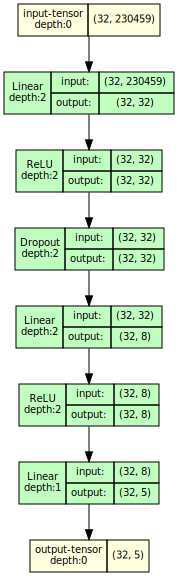

In [26]:
class EarlyIntegrationMLP(nn.Module):
    """
    A two-layer MLP for concatenated multi-omic features.

    Architecture
    ------------
    Input (all omics concatenated)
      → Linear(input_dim → hidden_dim) → ReLU → Dropout
      → Linear(hidden_dim → embedding_dim) → ReLU   [encoder]
      → Linear(embedding_dim → n_classes)            [classifier head]
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int = 128,
        embedding_dim: int = 32,
        n_classes: int = 2,
        dropout: float = 0.25,
    ) -> None:
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embedding_dim),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(embedding_dim, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.encoder(x))

    def embed(self, x: torch.Tensor) -> torch.Tensor:
        """Return the latent embedding (before the classification head)."""
        return self.encoder(x)


# ── Architecture diagram ──────────────────────────────────────────────────────
_early_model_for_graph = EarlyIntegrationMLP(
    input_dim=X_train_early.shape[1],
    hidden_dim=32,
    embedding_dim=8,
    n_classes=n_classes,
)

graph = draw_graph(
    _early_model_for_graph,
    input_size=(32, X_train_early.shape[1]),
    device="meta",
    graph_name="EarlyIntegrationMLP",
)
graph.visual_graph

In [ ]:
early_model = EarlyIntegrationMLP(
    input_dim=X_train_early.shape[1],
    hidden_dim=32,
    embedding_dim=8,
    n_classes=n_classes,
).to(device)

early_train_loader = make_loader(X_train_early, y_train, batch_size=1024, shuffle=True)
early_test_loader  = make_loader(X_test_early,  y_test,  batch_size=256, shuffle=False)

print("Training early-integration MLP …")
early_history = train_classifier(early_model, early_train_loader, n_epochs=150)

early_pred = predict(early_model, early_test_loader)
evaluate_predictions(y_test, early_pred, "Early Integration MLP")

Training early-integration MLP …
  Epoch 010/150 | loss = 1.2604
  Epoch 020/150 | loss = 0.7045
  Epoch 030/150 | loss = 0.4097


## 6. Multi-modal encoder network

A **multi-modal encoder** keeps each omic separated at the input.

```
transcriptomics ──► Encoder_T ──┐
proteomics      ──► Encoder_P ──┼──► concat ──► Classifier ──► subtype
methylation     ──► Encoder_M ──┘
```

Each omic-specific encoder learns features relevant to that data type.  
The per-omic embeddings are concatenated into a **joint multi-omic representation** used for subtype prediction.

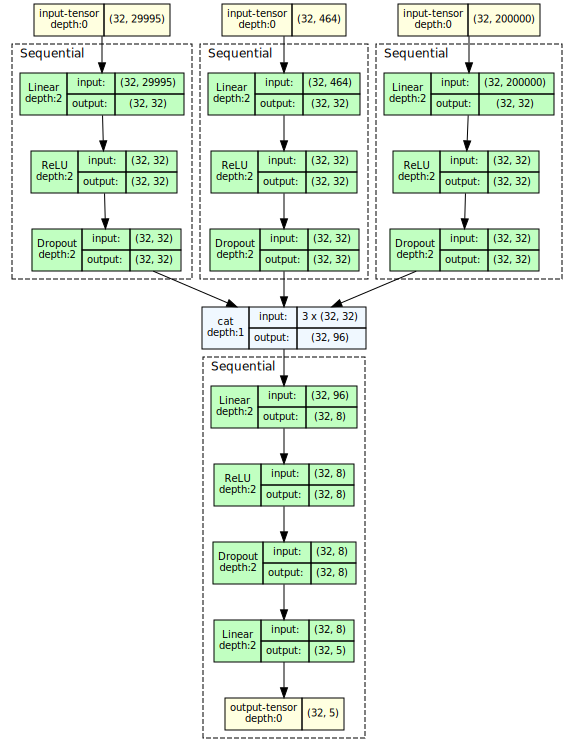

In [24]:
class MultiOmicEncoder(nn.Module):
    """
    One independent encoder per omic view, followed by a shared classifier.

    Architecture
    ------------
    For each omic view:
      Input_i → Linear(dim_i → hidden_dim) → ReLU → Dropout
              → Linear(hidden_dim → view_embedding_dim) → ReLU

    Then:
      concat(all view embeddings)
        → Linear(joint_dim → hidden_dim) → ReLU → Dropout
        → Linear(hidden_dim → n_classes)
    """

    def __init__(
        self,
        input_dims: dict[str, int],
        view_embedding_dim: int = 16,
        hidden_dim: int = 64,
        n_classes: int = 2,
        dropout: float = 0.25,
    ) -> None:
        super().__init__()

        self.view_names = list(input_dims.keys())

        # One small encoder per omic view.
        self.encoders = nn.ModuleDict({
            name: nn.Sequential(
                nn.Linear(dim, view_embedding_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            )
            for name, dim in input_dims.items()
        })

        joint_dim = view_embedding_dim * len(input_dims)

        # Shared classifier over the concatenated embeddings.
        self.classifier = nn.Sequential(
            nn.Linear(joint_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, *views: torch.Tensor) -> torch.Tensor:
        joint = torch.cat(
            [self.encoders[name](x) for name, x in zip(self.view_names, views)],
            dim=1,
        )
        return self.classifier(joint)

    def embed(self, *views: torch.Tensor) -> torch.Tensor:
        """Return the joint embedding (concatenated per-omic embeddings)."""
        return torch.cat(
            [self.encoders[name](x) for name, x in zip(self.view_names, views)],
            dim=1,
        )


# ── Architecture diagram ──────────────────────────────────────────────────────
_multi_model_for_graph = MultiOmicEncoder(
    input_dims=input_dims,
    view_embedding_dim=32,
    hidden_dim=8,
    n_classes=n_classes,
)

# Build one dummy tensor per omic view for the graph pass.
_dummy_inputs = tuple(
    torch.zeros(32, dim) for dim in input_dims.values()
)

multi_graph = draw_graph(
    _multi_model_for_graph,
    input_data=list(_dummy_inputs),
    device="meta",
    graph_name="MultiOmicEncoder",
    expand_nested=True,
)
multi_graph.visual_graph

In [29]:
multi_model = MultiOmicEncoder(
    input_dims=input_dims,
    view_embedding_dim=32,
    hidden_dim=8,
    n_classes=n_classes,
).to(device)

multi_train_loader = make_multiview_loader(X_train_views, y_train, batch_size=1024, shuffle=True)
multi_test_loader  = make_multiview_loader(X_test_views,  y_test,  batch_size=256, shuffle=False)

print("Training multi-modal encoder …")
multi_history = train_classifier(multi_model, multi_train_loader, n_epochs=250)

multi_pred = predict(multi_model, multi_test_loader)
evaluate_predictions(y_test, multi_pred, "Multi-Modal Encoder Network")

Training multi-modal encoder …
  Epoch 010/250 | loss = 1.1245
  Epoch 020/250 | loss = 0.6040
  Epoch 030/250 | loss = 0.5044
  Epoch 040/250 | loss = 0.4669
  Epoch 050/250 | loss = 0.3402
  Epoch 060/250 | loss = 0.3466
  Epoch 070/250 | loss = 0.2772
  Epoch 080/250 | loss = 0.3004
  Epoch 090/250 | loss = 0.2692
  Epoch 100/250 | loss = 0.2758
  Epoch 110/250 | loss = 0.2270
  Epoch 120/250 | loss = 0.2395
  Epoch 130/250 | loss = 0.2772
  Epoch 140/250 | loss = 0.2337
  Epoch 150/250 | loss = 0.2665
  Epoch 160/250 | loss = 0.2839
  Epoch 170/250 | loss = 0.2379
  Epoch 180/250 | loss = 0.2024
  Epoch 190/250 | loss = 0.2090
  Epoch 200/250 | loss = 0.1963
  Epoch 210/250 | loss = 0.2259
  Epoch 220/250 | loss = 0.2801
  Epoch 230/250 | loss = 0.2195
  Epoch 240/250 | loss = 0.1809
  Epoch 250/250 | loss = 0.3305

Multi-Modal Encoder Network
───────────────────────────
  Accuracy          : 0.800
  Balanced accuracy : 0.721

              precision    recall  f1-score   support



## 7. Compare model performance

Because both models used the **same** train/test split, the comparison is direct.

In [30]:
results = pd.DataFrame({
    "Model": ["Early Integration MLP", "Multi-Modal Encoder"],
    "Accuracy": [
        accuracy_score(y_test, early_pred),
        accuracy_score(y_test, multi_pred),
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, early_pred),
        balanced_accuracy_score(y_test, multi_pred),
    ],
})

display(results.sort_values("Balanced Accuracy", ascending=False).reset_index(drop=True))

,Model,Accuracy,Balanced Accuracy
0,Early Integration MLP,0.824,0.795000
1,Multi-Modal Encoder,0.800,0.720667


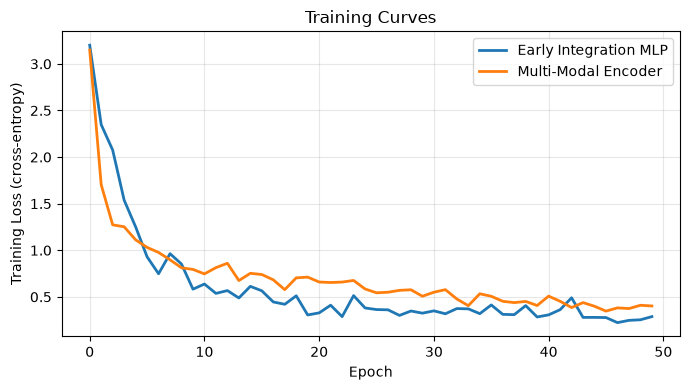

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(early_history, label="Early Integration MLP", linewidth=2)
ax.plot(multi_history, label="Multi-Modal Encoder",   linewidth=2)

ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss (cross-entropy)")
ax.set_title("Training Curves")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Inspect the learned multi-omic embedding space

The multi-modal encoder produces one compact vector per patient — a **learned multi-omic profile**.

We can visualise this embedding in three ways:

| Method | What it shows |
|--------|---------------|
| **PCA** | Linear projection preserving global variance |
| **t-SNE** | Non-linear projection emphasising local cluster structure |
| **UMAP** | Non-linear projection preserving local neighbourhood structure while better maintaining global structure than t‑SNE|

Here, we will just show the output from t-SNE

[Early] Train embedding : (375, 5)
[Early] Test  embedding : (125, 5)
[Multi] Train embedding : (375, 5)
[Multi] Test  embedding : (125, 5)


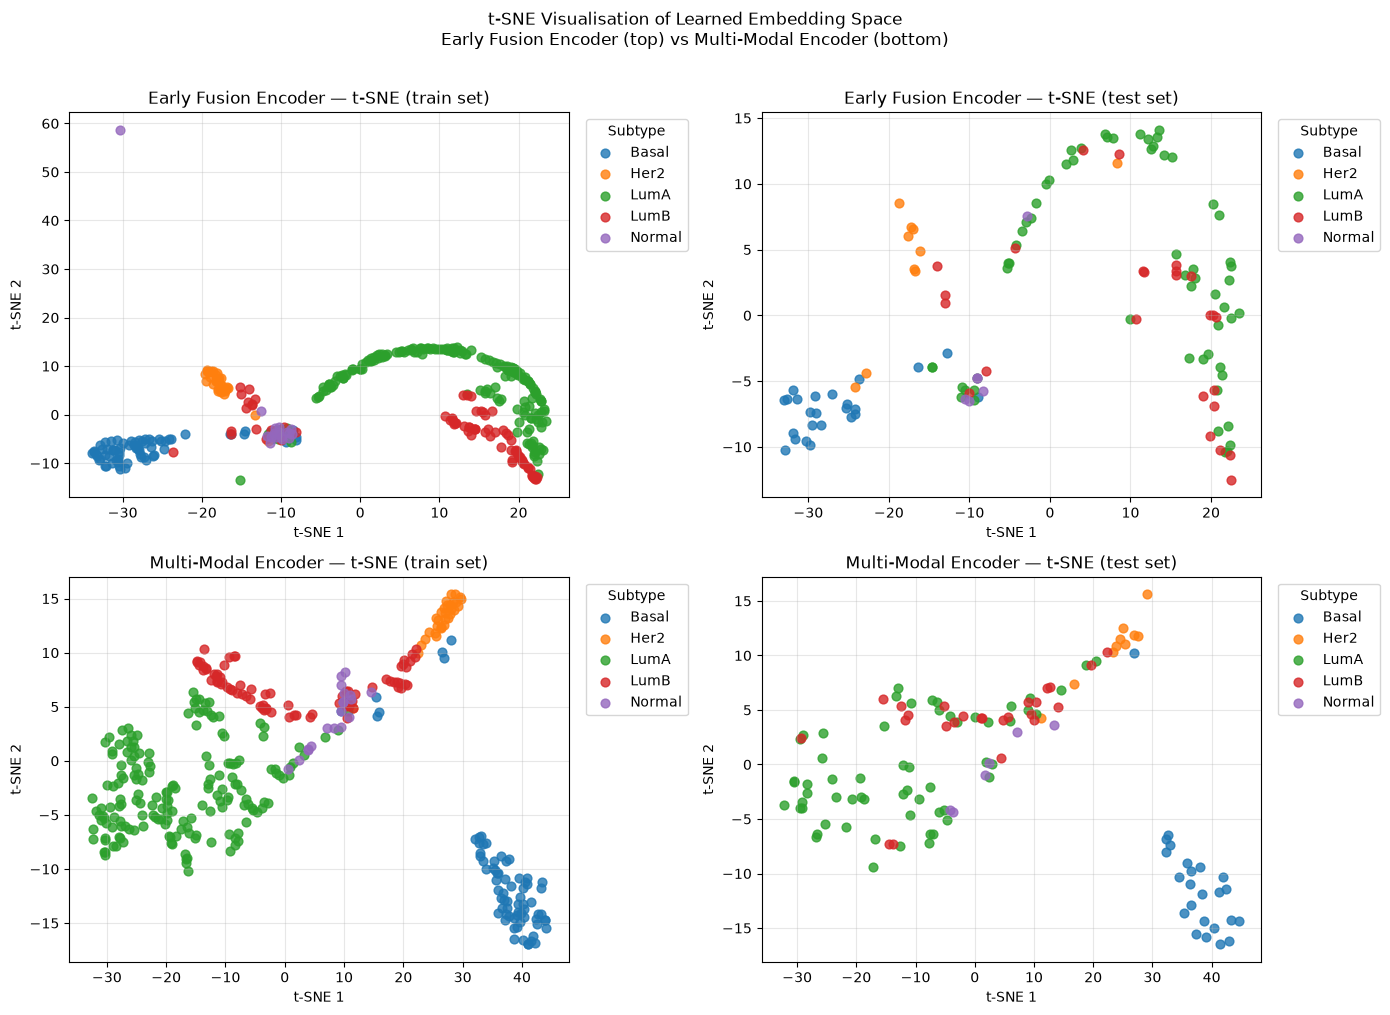

In [13]:
# Early fusion model — embeddings from train and test splits.
train_emb_early, train_emb_y_early = get_embeddings(early_model, early_train_loader)
test_emb_early,  test_emb_y_early  = get_embeddings(early_model, early_test_loader)

print(f"[Early] Train embedding : {train_emb_early.shape}")
print(f"[Early] Test  embedding : {test_emb_early.shape}")

# Multi-modal model — embeddings from train and test splits.
train_emb_multi, train_emb_y_multi = get_embeddings(multi_model, multi_train_loader)
test_emb_multi,  test_emb_y_multi  = get_embeddings(multi_model, multi_test_loader)

print(f"[Multi] Train embedding : {train_emb_multi.shape}")
print(f"[Multi] Test  embedding : {test_emb_multi.shape}")

# ── t-SNE projections ─────────────────────────────────────────────────────────
# Fit t-SNE on all available embeddings (train + test) for a stable layout.
# Done separately per model so each projection reflects its own embedding space.

# Early fusion model t-SNE
all_emb_early = np.vstack([train_emb_early, test_emb_early])
all_y_early   = np.concatenate([train_emb_y_early, test_emb_y_early])

all_tsne_early = TSNE(
    n_components=2,
    perplexity=30,
    random_state=RANDOM_STATE,
    init="pca",
).fit_transform(all_emb_early)

n_train_early = len(train_emb_early)
tsne_df_early = pd.DataFrame({
    "TSNE1":   all_tsne_early[:, 0],
    "TSNE2":   all_tsne_early[:, 1],
    "subtype": label_encoder.inverse_transform(all_y_early),
    "split":   ["train"] * n_train_early + ["test"] * len(test_emb_early),
})

# Multi-modal model t-SNE
all_emb_multi = np.vstack([train_emb_multi, test_emb_multi])
all_y_multi   = np.concatenate([train_emb_y_multi, test_emb_y_multi])

all_tsne_multi = TSNE(
    n_components=2,
    perplexity=30,
    random_state=RANDOM_STATE,
    init="pca",
).fit_transform(all_emb_multi)

n_train_multi = len(train_emb_multi)
tsne_df_multi = pd.DataFrame({
    "TSNE1":   all_tsne_multi[:, 0],
    "TSNE2":   all_tsne_multi[:, 1],
    "subtype": label_encoder.inverse_transform(all_y_multi),
    "split":   ["train"] * n_train_multi + ["test"] * len(test_emb_multi),
})

# ── Combined 2 × 2 visualisation ─────────────────────────────────────────────
# Rows  = model (Early Fusion / Multi-Modal)
# Cols  = data split (train / test)
# Shared layout makes the two models directly comparable.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

configs = [
    (axes[0], tsne_df_early, "Early Fusion Encoder"),
    (axes[1], tsne_df_multi, "Multi-Modal Encoder"),
]

for row_axes, tsne_df, model_name in configs:
    for ax, split in zip(row_axes, ["train", "test"]):
        subset = tsne_df[tsne_df["split"] == split]
        for subtype in class_names:
            mask = subset["subtype"] == subtype
            ax.scatter(subset.loc[mask, "TSNE1"], subset.loc[mask, "TSNE2"],
                       label=subtype, alpha=0.8, s=40)
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        ax.set_title(f"{model_name} — t-SNE ({split} set)")
        ax.legend(title="Subtype", bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.grid(True, alpha=0.3)

plt.suptitle(
    "t-SNE Visualisation of Learned Embedding Space\n"
    "Early Fusion Encoder (top) vs Multi-Modal Encoder (bottom)",
    y=1.01,
)
plt.tight_layout()
plt.show()


## 9. Per-omic encoder embedding spaces (t-SNE)

The joint t-SNE in Section 8 visualised the *combined* multi-omic embedding.
Here we look inside the model and visualise what each **individual omic encoder** has learned.

Each encoder maps its raw input (e.g. ~20,000 transcriptomic features) down to a
`view_embedding_dim`-dimensional vector. We run t-SNE on those per-omic embeddings
separately to ask:

> *How much subtype structure does each omic view contribute on its own?*

| Omic | Input features | Encoded to |
|------|---------------|------------|
| Transcriptomics | ~20,000 genes | `view_embedding_dim` |
| Proteomics | ~200 proteins | `view_embedding_dim` |
| Methylation | ~20,000 CpG sites | `view_embedding_dim` |

**What to look for**

- **Well-separated clusters** → that omic alone carries strong subtype signal.
- **Mixed / overlapping clusters** → the omic contributes less on its own, but may
  still add complementary information when combined with the other views.
- **Train / test consistency** → similar cluster structure in both splits suggests the
  encoder has generalised rather than memorised.

Note that `get_embeddings` is called here with `n_mod=i` to extract the output of
the *i*-th view encoder rather than the full joint embedding.

Generate Train and Test Embedding for transcriptomics


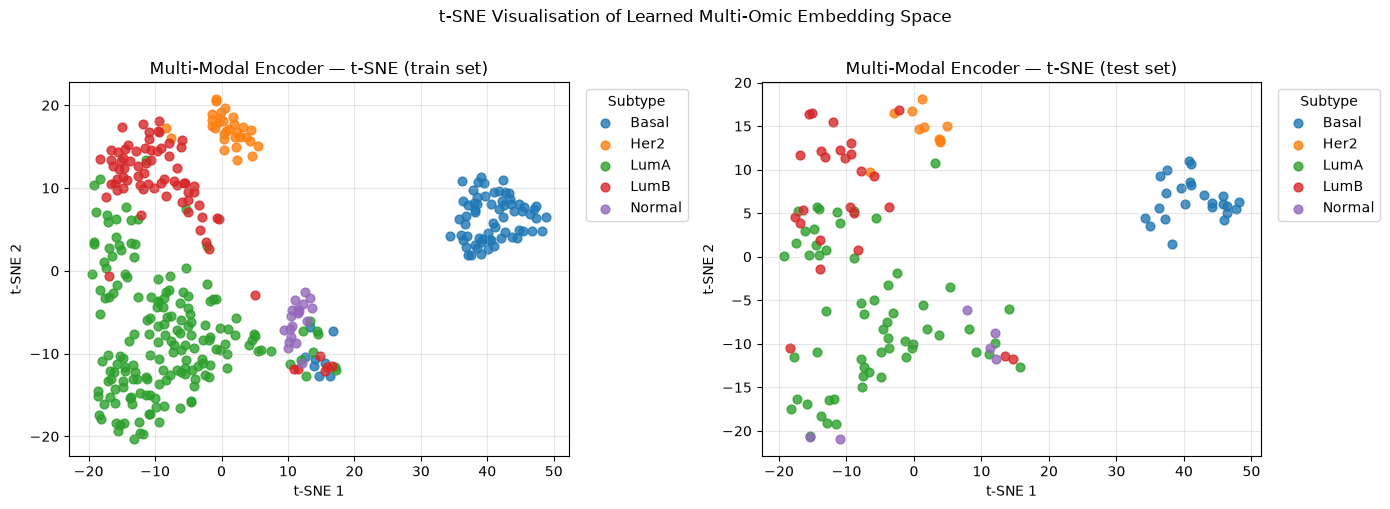

Generate Train and Test Embedding for proteomics


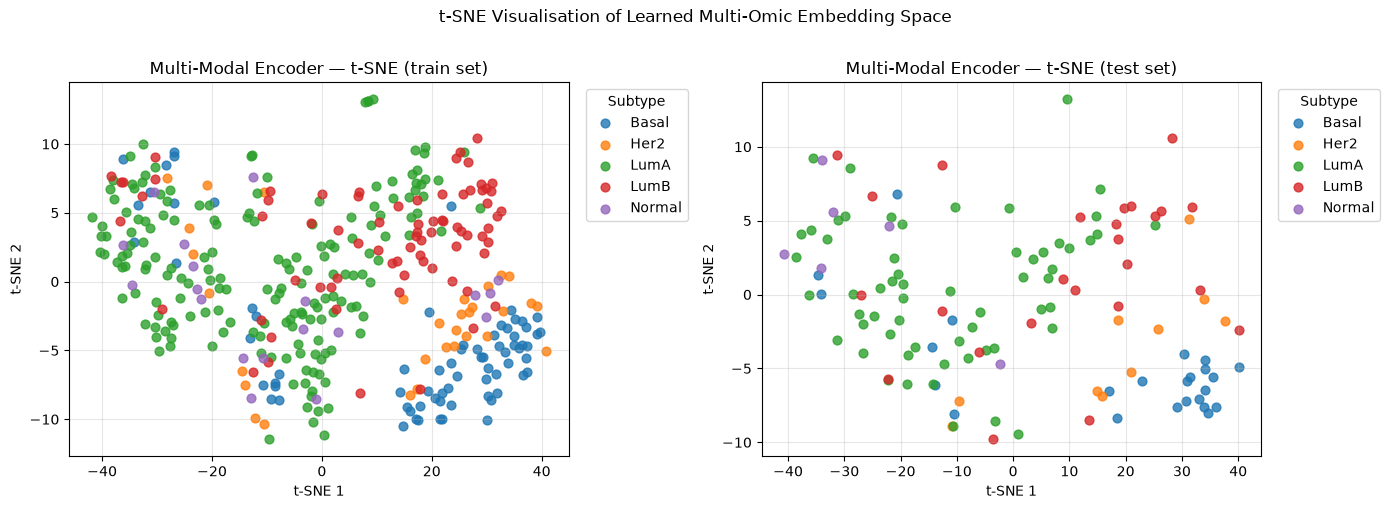

Generate Train and Test Embedding for methylation


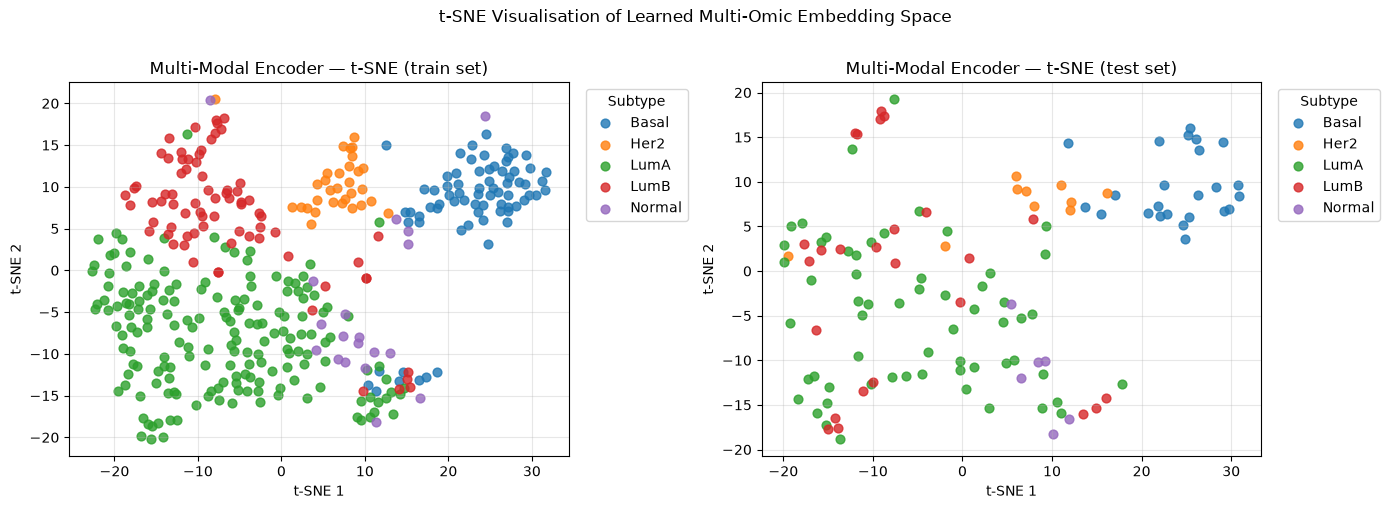

In [14]:
for i , mod in enumerate(['transcriptomics' , 'proteomics' , 'methylation']) : 
    print(f'Generate Train and Test Embedding for {mod}')
    train_emb, train_emb_y = get_embeddings(multi_model.encoders[mod], multi_train_loader , n_mod = i)
    test_emb, test_emb_y = get_embeddings(multi_model.encoders[mod], multi_test_loader , n_mod = i)
    
    # ── t-SNE projection ─────────────────────────────────────────────────────────
    # Fit t-SNE on all available embeddings (train + test) for a stable layout,
    # then colour by the known test labels.
    all_emb = np.vstack([train_emb, test_emb])
    all_y   = np.concatenate([train_emb_y, test_emb_y])
    
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=RANDOM_STATE,
        init="pca",
    )
    all_tsne = tsne.fit_transform(all_emb)
    
    # Split back into train / test for colouring.
    n_train = len(train_emb)
    tsne_df = pd.DataFrame({
        "TSNE1":   all_tsne[:, 0],
        "TSNE2":   all_tsne[:, 1],
        "subtype": label_encoder.inverse_transform(all_y),
        "split":   ["train"] * n_train + ["test"] * len(test_emb),
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, split in zip(axes, ["train", "test"]):
        subset = tsne_df[tsne_df["split"] == split]
        for subtype in class_names:
            mask = subset["subtype"] == subtype
            ax.scatter(subset.loc[mask, "TSNE1"], subset.loc[mask, "TSNE2"],
                       label=subtype, alpha=0.8, s=40)
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        ax.set_title(f"Multi-Modal Encoder — t-SNE ({split} set)")
        ax.legend(title="Subtype", bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.grid(True, alpha=0.3)
    
    plt.suptitle("t-SNE Visualisation of Learned Multi-Omic Embedding Space", y=1.01)
    plt.tight_layout()
    plt.show()

## 10. Gradient-based feature importance (Integrated Gradients)

**Which input features does the model rely on most?**

### Method: Integrated Gradients

Vanilla gradients measure the local slope at the input — they can be noisy and  
saturate near decision boundaries. **Integrated Gradients (IG)** fixes this by  
averaging gradients along a straight path from a neutral baseline (zeros) to the  
actual input:

$$\text{IG}_j(x) = (x_j - x_j^{\text{ref}}) \times \int_0^1 \frac{\partial F(x^{\text{ref}} + \alpha(x - x^{\text{ref}}))}{\partial x_j}\, d\alpha$$

**Key properties**
| Property | Meaning |
|----------|---------|
| **Completeness** | Attributions sum exactly to the model output difference from baseline |
| **Sensitivity** | A feature that changes the output always gets non-zero attribution |
| **Sign-aware** | Positive = pushes toward predicted class; negative = pushes away |
| **Implementation cost** | `n_steps` forward+backward passes regardless of feature count |

In [15]:
def integrated_gradients(
    model: nn.Module,
    X_views: dict[str, np.ndarray],
    y: np.ndarray,
    n_steps: int = 50,
    batch_size: int = 128,
    device: torch.device = device,
) -> tuple[np.ndarray, np.ndarray, list[str]]:
    """
    Compute Integrated Gradients attributions for a multi-view classifier.

    The reference baseline is the zero vector (mean-centred features are
    already centred around zero, so this represents an uninformative patient).

    How it works
    ------------
    For each interpolation step α ∈ {0/n, 1/n, …, n/n}:
      1. Build interpolated inputs:  x_ref + α * (x - x_ref)
      2. Run a forward pass to get the logit for the *predicted* class.
      3. Run a backward pass to get ∂logit / ∂x_j  for every feature j.
    Average the gradients across all steps, then multiply by (x - x_ref).
    This satisfies the completeness axiom exactly (up to quadrature error).

    Complexity
    ----------
    O(n_steps × N / batch_size) forward+backward passes,
    independent of the number of features D.

    Parameters
    ----------
    model      : trained model (MultiOmicEncoder or any *views forward signature)
    X_views    : {view_name: float32 array (N, D_i)}
    y          : integer label array (N,) — used to pick the target logit
    n_steps    : number of Riemann steps (50 is accurate; 20 is fast)
    batch_size : patients per mini-batch (reduce if GPU OOM)
    device     : torch device

    Returns
    -------
    attributions : np.ndarray (N, D_total) — per-patient, per-feature attribution
    mean_attrs   : np.ndarray (D_total,)   — mean |attribution| across patients
    feature_names: list[str]               — "view:index" label per column
    """
    model.eval()
    model.to(device)

    view_names = list(X_views.keys())
    view_dims  = [X_views[name].shape[1] for name in view_names]
    N          = next(iter(X_views.values())).shape[0]
    D_total    = sum(view_dims)
    boundaries = np.cumsum([0] + view_dims)

    # ── Pre-load to GPU ───────────────────────────────────────────────────────
    Xg = [
        torch.tensor(X_views[name], dtype=torch.float32, device=device)
        for name in view_names
    ]
    yg = torch.tensor(y, dtype=torch.long, device=device)

    # Baseline = zeros (features are StandardScaler-normalised, so 0 = mean patient)
    baselines = [torch.zeros_like(x) for x in Xg]
    deltas    = [x - b for x, b in zip(Xg, baselines)]   # (x - x_ref) per view

    # Accumulator: sum of gradients across steps, shape (N, D_total)
    grad_sum = torch.zeros(N, D_total, device=device)

    # ── Riemann integration over interpolation steps ──────────────────────────
    alphas = torch.linspace(0, 1, n_steps + 1, device=device)   # [0, 1/n, ..., 1]

    for alpha in alphas:
        # Interpolated inputs for this step.
        interp = [b + alpha * d for b, d in zip(baselines, deltas)]

        # Process in mini-batches to control GPU memory.
        for start in range(0, N, batch_size):
            sl      = slice(start, start + batch_size)
            batch   = [v[sl].detach().requires_grad_(True) for v in interp]
            targets = yg[sl]

            logits  = model(*batch)

            # Score = logit of the true class (measures confidence in correct label).
            score = logits.gather(1, targets.unsqueeze(1)).squeeze(1).sum()
            score.backward()

            # Collect gradients from each view and concatenate along feature axis.
            grads = torch.cat([b.grad for b in batch], dim=1)   # (batch, D_total)
            grad_sum[start:start + grads.shape[0]] += grads.detach()

    # Trapezoidal correction: all interior steps counted once, endpoints halved.
    grad_sum = grad_sum / n_steps

    # Multiply averaged gradient by (x - baseline).
    delta_cat    = torch.cat(deltas, dim=1)                   # (N, D_total)
    attributions = (grad_sum * delta_cat).cpu().numpy()       # (N, D_total)

    # Mean absolute attribution across patients → one importance score per feature.
    mean_attrs = np.abs(attributions).mean(axis=0)            # (D_total,)

    # Human-readable labels.
    feature_names = []
    for name, dim in zip(view_names, view_dims):
        feature_names.extend([f"{name}:{i}" for i in range(dim)])

    return attributions, mean_attrs, feature_names


# ── Run ───────────────────────────────────────────────────────────────────────
n_features = sum(X_test_views[k].shape[1] for k in X_test_views)
print(f"Running Integrated Gradients …")
print(f"  Features : {n_features:,}  (scored simultaneously)")
print(f"  Steps    : 50")
print(f"  Device   : {device}\n")

attributions, mean_attrs, feature_names = integrated_gradients(
    multi_model,
    X_views=X_test_views,
    y=y_test,
    n_steps=50,
    batch_size=128,
    device=device,
)

print(f"Attribution matrix : {attributions.shape}  (patients × features)")
print(f"Total features     : {len(mean_attrs):,}")

topk_idx = np.argsort(mean_attrs)[::-1][:10]
print("\nTop 10 features by mean |attribution|:")
for rank, j in enumerate(topk_idx, 1):
    print(f"  {rank:2d}. {feature_names[j]:30s}  |attr| = {mean_attrs[j]:.5f}")

Running Integrated Gradients …
  Features : 230,459  (scored simultaneously)
  Steps    : 50
  Device   : cuda

Attribution matrix : (125, 230459)  (patients × features)
Total features     : 230,459

Top 10 features by mean |attribution|:
   1. transcriptomics:21761           |attr| = 0.01264
   2. transcriptomics:26977           |attr| = 0.01166
   3. proteomics:124                  |attr| = 0.01151
   4. transcriptomics:29739           |attr| = 0.01145
   5. transcriptomics:27224           |attr| = 0.01136
   6. proteomics:176                  |attr| = 0.01119
   7. transcriptomics:22694           |attr| = 0.01117
   8. transcriptomics:5667            |attr| = 0.01114
   9. transcriptomics:3925            |attr| = 0.01100
  10. proteomics:164                  |attr| = 0.01085


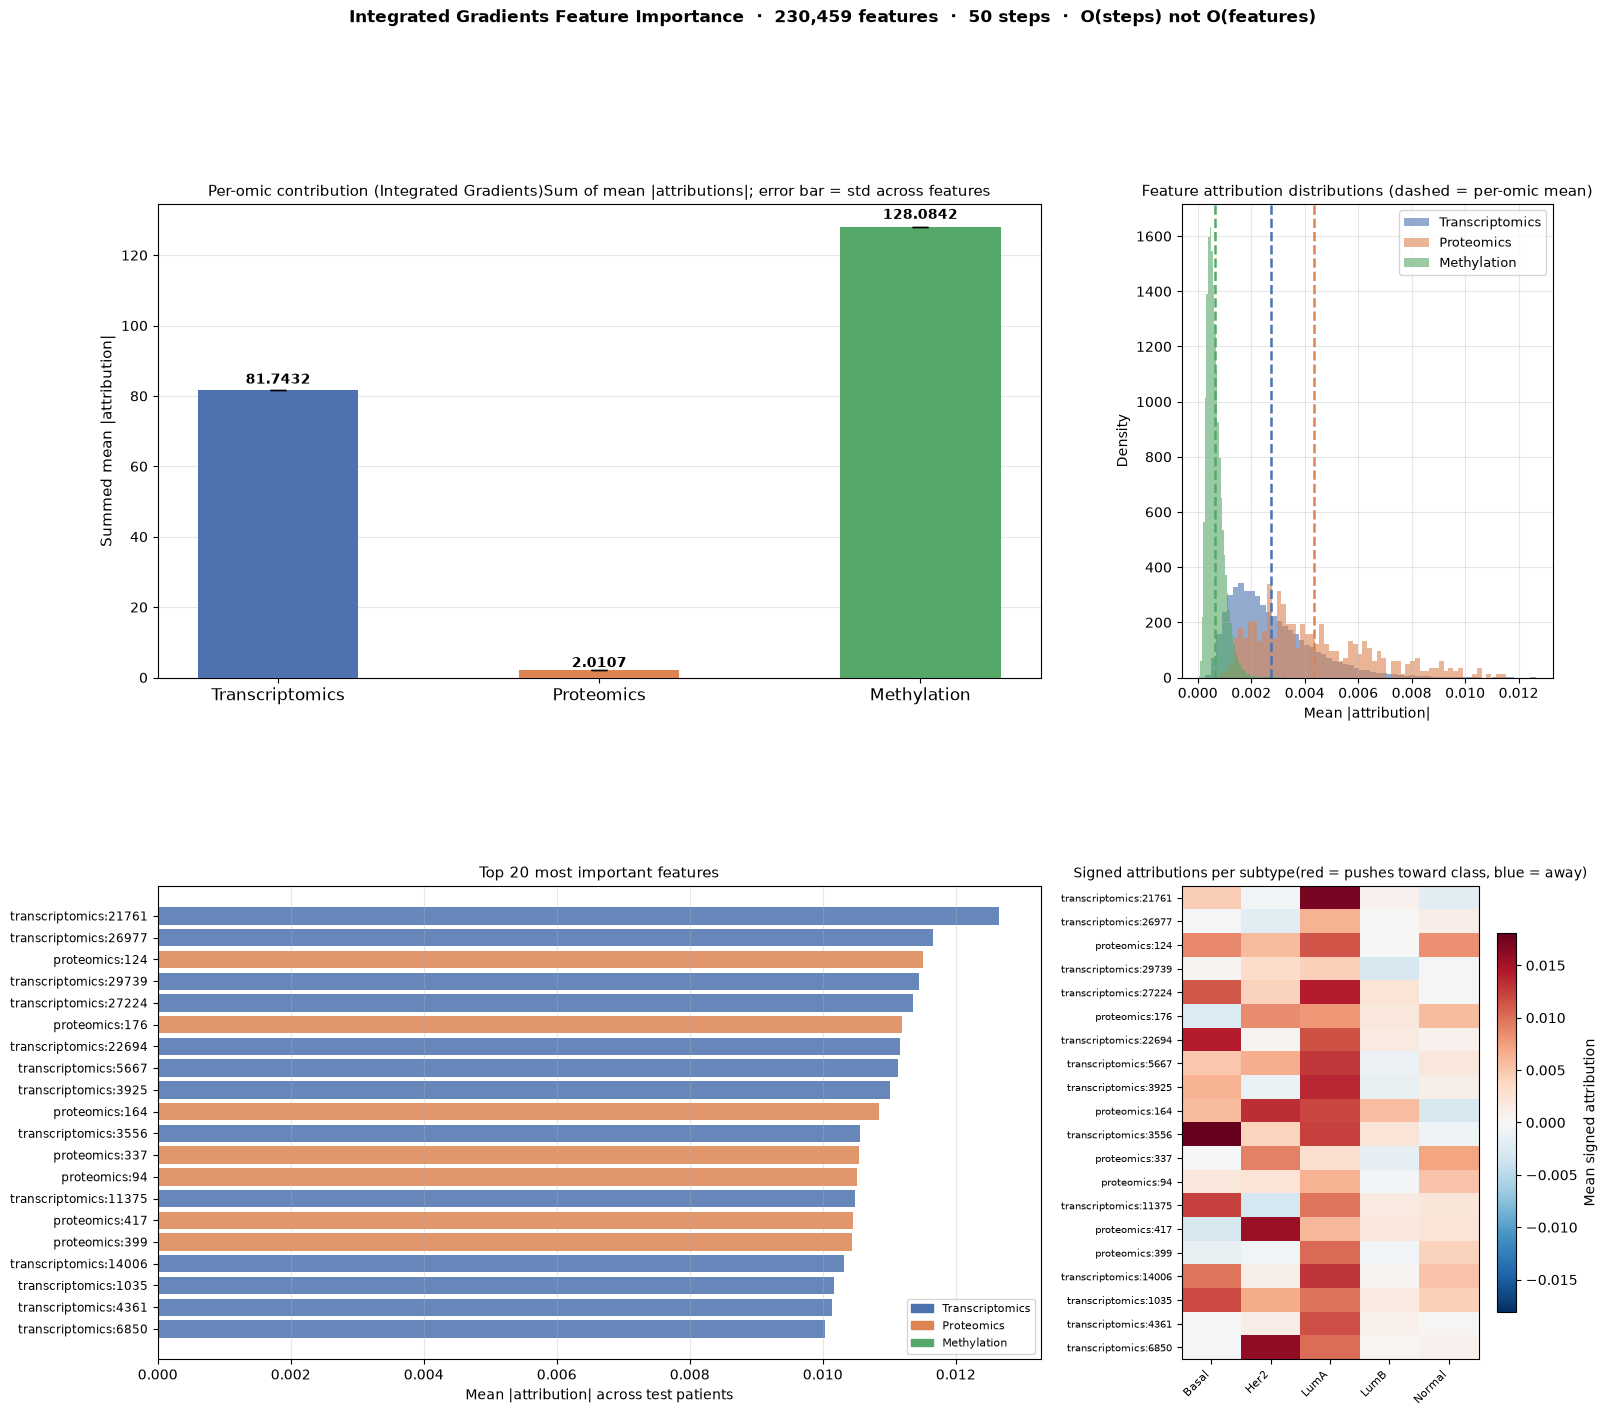

In [16]:
# ── Setup ─────────────────────────────────────────────────────────────────────
view_names_ordered = list(X_test_views.keys())
view_dims          = [X_test_views[k].shape[1] for k in view_names_ordered]
boundaries         = np.cumsum([0] + view_dims)

omic_colors = {
    "transcriptomics": "#4C72B0",
    "proteomics":      "#DD8452",
    "methylation":     "#55A868",
}

# Per-view slices of mean attributions.
view_attrs = {
    name: mean_attrs[boundaries[i]:boundaries[i + 1]]
    for i, name in enumerate(view_names_ordered)
}

# Per-view slices of signed attributions (N, D_i) for the heatmap.
view_signed = {
    name: attributions[:, boundaries[i]:boundaries[i + 1]]
    for i, name in enumerate(view_names_ordered)
}

# ── Figure: 4 panels ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 15))
gs  = fig.add_gridspec(2, 3, hspace=0.44, wspace=0.38)

ax_agg  = fig.add_subplot(gs[0, :2])   # top-left wide: per-omic aggregate
ax_dist = fig.add_subplot(gs[0, 2])    # top-right: attribution distributions
ax_top  = fig.add_subplot(gs[1, :2])   # bottom-left wide: top-k features
ax_heat = fig.add_subplot(gs[1, 2])    # bottom-right: per-subtype heatmap

# ── Panel 1: Per-omic aggregate mean |attribution| ───────────────────────────
agg_vals = [view_attrs[n].sum() for n in view_names_ordered]
agg_stds = [view_attrs[n].std() for n in view_names_ordered]
x_pos    = np.arange(len(view_names_ordered))

bars = ax_agg.bar(
    x_pos, agg_vals,
    color=[omic_colors[n] for n in view_names_ordered],
    width=0.5, zorder=3,
)
ax_agg.errorbar(x_pos, agg_vals, yerr=agg_stds,
                fmt="none", color="black", capsize=6, linewidth=1.5, zorder=4)
ax_agg.set_xticks(x_pos)
ax_agg.set_xticklabels([n.capitalize() for n in view_names_ordered], fontsize=12)
ax_agg.set_ylabel("Summed mean |attribution|", fontsize=11)
ax_agg.set_title("Per-omic contribution (Integrated Gradients)"
                 "Sum of mean |attributions|; error bar = std across features", fontsize=11)
ax_agg.grid(True, axis="y", alpha=0.3, zorder=0)
for bar, val in zip(bars, agg_vals):
    ax_agg.text(bar.get_x() + bar.get_width() / 2, val * 1.01,
                f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# ── Panel 2: Attribution distributions per omic ──────────────────────────────
for name in view_names_ordered:
    vals = view_attrs[name]
    ax_dist.hist(vals, bins=60, alpha=0.6, color=omic_colors[name],
                 label=name.capitalize(), density=True)
    ax_dist.axvline(vals.mean(), color=omic_colors[name], linestyle="--", linewidth=1.8)

ax_dist.set_xlabel("Mean |attribution|", fontsize=10)
ax_dist.set_ylabel("Density", fontsize=10)
ax_dist.set_title("Feature attribution distributions (dashed = per-omic mean)", fontsize=11)
ax_dist.legend(fontsize=9)
ax_dist.grid(True, alpha=0.3)

# ── Panel 3: Top-20 individual features (horizontal bar) ─────────────────────
TOP_K    = 20
topk     = np.argsort(mean_attrs)[::-1][:TOP_K]
top_vals = mean_attrs[topk]
top_lbls = [feature_names[j] for j in topk]
top_cols = [omic_colors[feature_names[j].split(":")[0]] for j in topk]
y_pos    = np.arange(TOP_K)[::-1]

ax_top.barh(y_pos, top_vals, color=top_cols, align="center", alpha=0.85)
ax_top.set_yticks(y_pos)
ax_top.set_yticklabels(top_lbls, fontsize=8.5)
ax_top.set_xlabel("Mean |attribution| across test patients", fontsize=10)
ax_top.set_title(f"Top {TOP_K} most important features", fontsize=11)
ax_top.grid(True, axis="x", alpha=0.3)

patches = [plt.Rectangle((0, 0), 1, 1, color=omic_colors[n]) for n in view_names_ordered]
ax_top.legend(patches, [n.capitalize() for n in view_names_ordered],
              loc="lower right", fontsize=8)

# ── Panel 4: Signed attribution heatmap — top features × subtype ─────────────
# Average signed attributions per subtype across the top-20 features.
subtypes      = label_encoder.inverse_transform(y_test)
unique_sub    = class_names
top_feat_lbls = [feature_names[j] for j in topk]

heatmap_data = np.zeros((TOP_K, len(unique_sub)))
for s_i, sub in enumerate(unique_sub):
    mask = subtypes == sub
    # Mean signed attribution for each top feature, averaged over patients of this subtype.
    heatmap_data[:, s_i] = attributions[mask][:, topk].mean(axis=0)

# Diverging colormap centred at 0.
vmax = np.abs(heatmap_data).max()
im   = ax_heat.imshow(heatmap_data, aspect="auto", cmap="RdBu_r",
                      vmin=-vmax, vmax=vmax)
ax_heat.set_xticks(np.arange(len(unique_sub)))
ax_heat.set_xticklabels(unique_sub, rotation=45, ha="right", fontsize=8)
ax_heat.set_yticks(np.arange(TOP_K))
ax_heat.set_yticklabels(top_feat_lbls, fontsize=7.5)
ax_heat.set_title("Signed attributions per subtype"
                  "(red = pushes toward class, blue = away)", fontsize=10)
plt.colorbar(im, ax=ax_heat, shrink=0.8, label="Mean signed attribution")

plt.suptitle(
    f"Integrated Gradients Feature Importance  ·  {len(mean_attrs):,} features  ·  50 steps  ·  O(steps) not O(features)",
    fontsize=12, fontweight="bold", y=1.01,
)
plt.show()

## 11. Feature reduction and memory efficiency

The multi-modal encoder does not just learn better representations — it also produces a **dramatically smaller** patient profile.

This matters when embeddings are passed downstream (clustering, survival modelling, visualisation):

| Representation | Shape | What it is |
|----------------|-------|------------|
| Concatenated raw features | `n_patients × (T + P + M)` | All scaled input columns |
| Multi-omic embedding | `n_patients × (view_embedding_dim × n_views)` | Learned compact profile |

Below we quantify the reduction in dimensionality and memory footprint.

  Dimensionality
  Raw concatenated features :  230,459 columns
    └─ transcriptomics        :   29,995
    └─ proteomics             :      464
    └─ methylation            :  200,000
  Multi-omic embedding      :       32 columns
  Reduction factor          :   7201.8×
  Dimensionality saved      :   100.0 %

  Memory (all 500 patients, float32)
  Raw matrix   :    460.92 MB  (460,918,000 bytes)
  Embedding    :      64.0 KB  (64,000 bytes)
  Memory saved :    460.85 MB  (100.0 %)


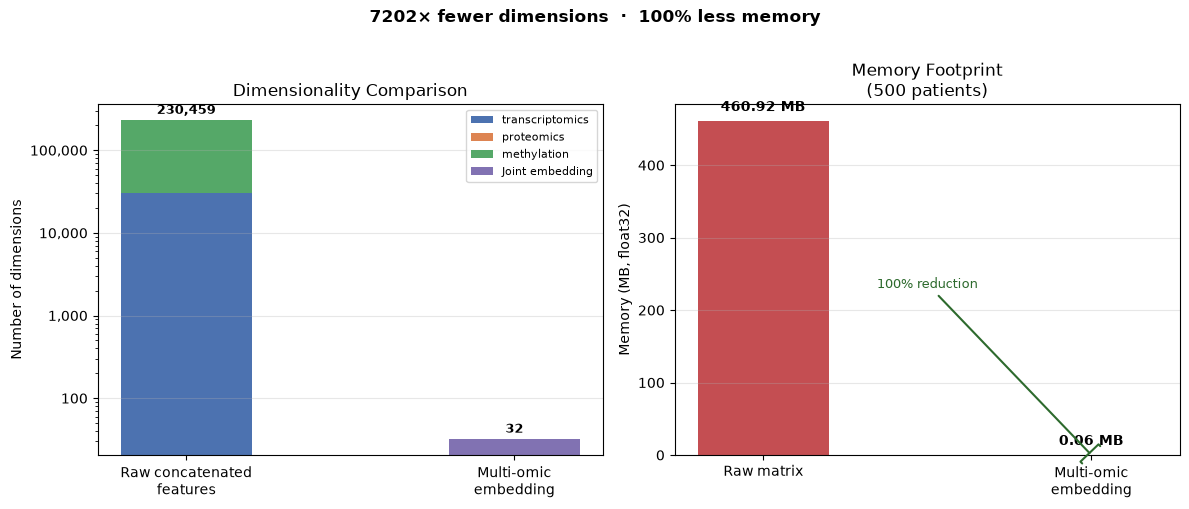

In [17]:
# ── Dimensions ────────────────────────────────────────────────────────────────
n_patients_train = X_train_early.shape[0]
n_patients_test  = X_test_early.shape[0]
n_patients_all   = n_patients_train + n_patients_test

raw_dim   = X_train_early.shape[1]      # all omics concatenated
embed_dim = train_emb.shape[1]          # learned embedding

reduction_factor = raw_dim / embed_dim
reduction_pct    = (1 - embed_dim / raw_dim) * 100

print("=" * 55)
print("  Dimensionality")
print("=" * 55)
print(f"  Raw concatenated features : {raw_dim:>8,d} columns")

for name, X in X_train_views.items():
    print(f"    └─ {name:15s}        : {X.shape[1]:>8,d}")

print(f"  Multi-omic embedding      : {embed_dim:>8,d} columns")
print(f"  Reduction factor          : {reduction_factor:>8.1f}×")
print(f"  Dimensionality saved      : {reduction_pct:>7.1f} %")

# ── Memory (float32 = 4 bytes) ────────────────────────────────────────────────
bytes_per_element = 4   # float32

raw_bytes   = n_patients_all * raw_dim   * bytes_per_element
embed_bytes = n_patients_all * embed_dim * bytes_per_element

def human_bytes(b):
    if b >= 1_000_000:
        return f"{b / 1_000_000:.2f} MB"
    if b >= 1_000:
        return f"{b / 1_000:.1f} KB"
    return f"{b} B"

print()
print("=" * 55)
print(f"  Memory (all {n_patients_all} patients, float32)")
print("=" * 55)
print(f"  Raw matrix   : {human_bytes(raw_bytes):>12s}  ({raw_bytes:,} bytes)")
print(f"  Embedding    : {human_bytes(embed_bytes):>12s}  ({embed_bytes:,} bytes)")
print(f"  Memory saved : {human_bytes(raw_bytes - embed_bytes):>12s}  ({(1 - embed_bytes/raw_bytes)*100:.1f} %)")

# ── Summary bar chart ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Panel 1: Dimensionality breakdown ---
ax = axes[0]

# Stacked bar showing per-omic contribution to raw vs embedding
view_dims   = [X.shape[1] for X in X_train_views.values()]
view_names  = list(X_train_views.keys())
view_colors = ["#4C72B0", "#DD8452", "#55A868"]

# Raw: stacked per-omic contributions
bottoms = 0
for dim, name, color in zip(view_dims, view_names, view_colors):
    ax.bar(0, dim, bottom=bottoms, color=color, width=0.4, label=name)
    bottoms += dim

# Embedding: single bar
ax.bar(1, embed_dim, width=0.4, color="#8172B2", label="Joint embedding")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Raw concatenated\nfeatures", "Multi-omic\nembedding"])
ax.set_ylabel("Number of dimensions")
ax.set_title("Dimensionality Comparison")
ax.legend(loc="upper right", fontsize=8)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(True, axis="y", alpha=0.3)

# Annotate
ax.text(0, raw_dim * 1.1, f"{raw_dim:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.text(1, embed_dim * 1.1, f"{embed_dim}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# --- Panel 2: Memory footprint ---
ax2 = axes[1]

labels  = ["Raw matrix", "Multi-omic\nembedding"]
sizes   = [raw_bytes / 1e6, embed_bytes / 1e6]
colors  = ["#C44E52", "#55A868"]

bars = ax2.bar(labels, sizes, color=colors, width=0.4)

ax2.set_ylabel("Memory (MB, float32)")
ax2.set_title(f"Memory Footprint\n({n_patients_all} patients)")
ax2.grid(True, axis="y", alpha=0.3)

for bar, val in zip(bars, sizes):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(sizes) * 0.02,
        f"{val:.2f} MB",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

# Annotate savings arrow
ax2.annotate(
    f"{reduction_pct:.0f}% reduction",
    xy=(1, sizes[1]),
    xytext=(0.5, (sizes[0] + sizes[1]) / 2),
    fontsize=9,
    color="#2d6a2d",
    ha="center",
    arrowprops=dict(arrowstyle="-[", color="#2d6a2d", lw=1.5),
)

plt.suptitle(
    f"{reduction_factor:.0f}× fewer dimensions  ·  {reduction_pct:.0f}% less memory",
    fontsize=12, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

## 12. Takeaways

### Early integration MLP
- Concatenates all omic features before modelling.
- Simple and useful as a baseline.
- Does not explicitly represent omic-specific structure.

### Multi-modal encoder
- Keeps each omic separate at the input.
- Learns omic-specific embeddings before combining them.
- Produces a compact patient-level embedding that can be reused downstream.
- Embedding structure (visible in PCA / t-SNE) reflects learned subtype information.

---

## Link to the next part

The key output from this section is the **multi-omic embedding matrix**.

In the next part, this representation can be used for:

- patient stratification and clustering
- survival modelling
- biological interpretation of latent patient profiles
- transfer to other tasks with limited labels